In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLear

In [3]:
import pandas as pd

file_path = "/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv"

df_sample = pd.read_csv(file_path, nrows=10000)

print("Sample Shape:", df_sample.shape)
print("\nColumns:")
print(df_sample.columns.tolist())

Sample Shape: (10000, 79)

Columns:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Co

In [4]:
print(df_sample[" Label"].value_counts())

 Label
BENIGN    10000
Name: count, dtype: int64


In [6]:
df_sample2 = pd.read_csv(
    file_path,
    skiprows=range(1, 100001),
    nrows=10000
)

print(df_sample2[" Label"].value_counts())

 Label
BENIGN    10000
Name: count, dtype: int64


In [7]:
df_random = pd.read_csv(
    file_path,
    skiprows=lambda x: x > 0 and __import__('random').random() > 0.01,
    nrows=10000
)

print("Shape:", df_random.shape)
print("\nLabel Distribution:")
print(df_random[" Label"].value_counts())

Shape: (5192, 79)

Label Distribution:
 Label
BENIGN    5192
Name: count, dtype: int64


In [8]:
attack_file = "/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv"

df_attack = pd.read_csv(
    attack_file,
    nrows=10000
)

print("Shape:", df_attack.shape)
print("\nLabel Distribution:")
print(df_attack[" Label"].value_counts())

Shape: (10000, 79)

Label Distribution:
 Label
BENIGN           9999
DoS slowloris       1
Name: count, dtype: int64


In [9]:
label_counts = {}

for chunk in pd.read_csv(attack_file, chunksize=50000):
    counts = chunk[" Label"].value_counts()

    for label, count in counts.items():
        label_counts[label] = label_counts.get(label, 0) + count

print(pd.Series(label_counts).sort_values(ascending=False))

BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
dtype: int64


In [10]:
print("Number of rows:", len(df_attack))
print("Number of columns:", len(df_attack.columns))

print("\nData Types:")
print(df_attack.dtypes.value_counts())

Number of rows: 10000
Number of columns: 79

Data Types:
int64      54
float64    24
object      1
Name: count, dtype: int64


In [11]:
missing_values = df_attack.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns with missing values:")
print(missing_values[missing_values > 0])

Total missing values: 4

Columns with missing values:
Flow Bytes/s    4
dtype: int64


In [12]:
print("Duplicate rows:", df_attack.duplicated().sum())

Duplicate rows: 71


In [13]:
print(df_attack[" Label"].value_counts())

 Label
BENIGN           9999
DoS slowloris       1
Name: count, dtype: int64


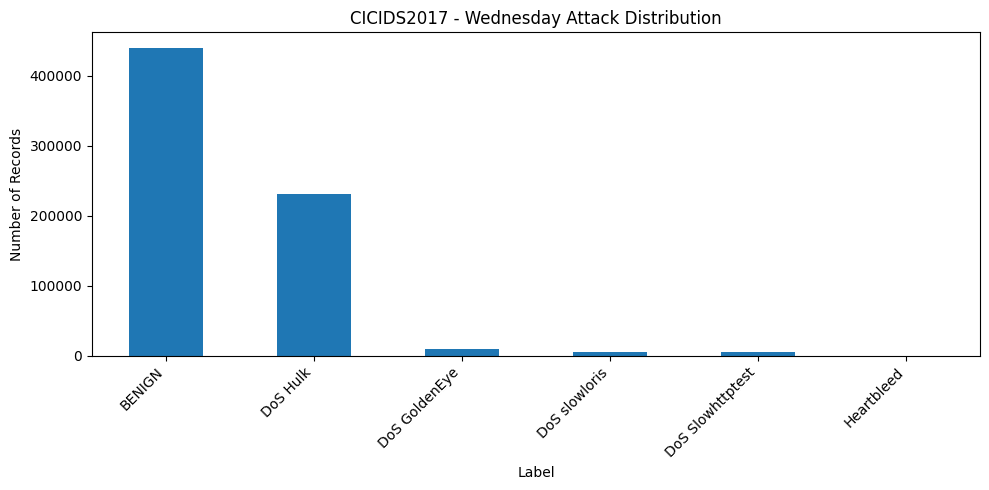

In [14]:
import matplotlib.pyplot as plt

labels = pd.Series(label_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
labels.plot(kind="bar")
plt.title("CICIDS2017 - Wednesday Attack Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
numeric_summary = df_attack.describe().T

print(numeric_summary[["mean", "std", "min", "max"]].head(15))

                                      mean           std         min  \
 Destination Port             7.197840e+03  1.648815e+04         0.0   
 Flow Duration                2.575258e+07  4.138235e+07        -1.0   
 Total Fwd Packets            2.207424e+02  5.976140e+03         1.0   
 Total Backward Packets       2.872283e+02  7.939816e+03         0.0   
Total Length of Fwd Packets   2.403694e+03  3.613941e+04         0.0   
 Total Length of Bwd Packets  6.234044e+05  1.748368e+07         0.0   
 Fwd Packet Length Max        3.510072e+02  9.801860e+02         0.0   
 Fwd Packet Length Min        1.241650e+01  2.497663e+01         0.0   
 Fwd Packet Length Mean       7.224808e+01  1.779099e+02         0.0   
 Fwd Packet Length Std        1.083202e+02  2.561139e+02         0.0   
Bwd Packet Length Max         8.163021e+02  1.211531e+03         0.0   
 Bwd Packet Length Min        2.281320e+01  5.353209e+01         0.0   
 Bwd Packet Length Mean       2.672356e+02  4.083177e+02        

In [17]:
import numpy as np

inf_counts = np.isinf(df_attack.select_dtypes(include=np.number)).sum()

print("Total infinite values:", inf_counts.sum())

print("\nColumns containing infinite values:")
print(inf_counts[inf_counts > 0])

Total infinite values: 30

Columns containing infinite values:
Flow Bytes/s       13
 Flow Packets/s    17
dtype: int64


In [19]:
correlation = df_attack.select_dtypes(include="number").corr()

high_corr = (
    correlation.abs()
    .where(~np.eye(correlation.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print(high_corr.head(20))

 Bwd Packet Length Mean        Avg Bwd Segment Size           1.000000
 Avg Bwd Segment Size          Bwd Packet Length Mean         1.000000
 Fwd Packet Length Mean        Avg Fwd Segment Size           1.000000
 ECE Flag Count                RST Flag Count                 1.000000
 Subflow Fwd Bytes            Total Length of Fwd Packets     1.000000
Total Length of Fwd Packets    Subflow Fwd Bytes              1.000000
Subflow Fwd Packets            Total Fwd Packets              1.000000
 Fwd Header Length.1           Fwd Header Length              1.000000
 Total Backward Packets        Subflow Bwd Packets            1.000000
 Total Fwd Packets            Subflow Fwd Packets             1.000000
 Avg Fwd Segment Size          Fwd Packet Length Mean         1.000000
 Fwd Header Length             Fwd Header Length.1            1.000000
 RST Flag Count                ECE Flag Count                 1.000000
 Subflow Bwd Packets           Total Backward Packets         1.000000
 SYN F

In [20]:
features = [
    " Destination Port",
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    " Packet Length Mean"
]

print(df_attack[features].describe().T)

                          count          mean           std  min      25%  \
Destination Port        10000.0  7.197840e+03  1.648815e+04  0.0    80.00   
Flow Duration           10000.0  2.575258e+07  4.138235e+07 -1.0  2025.00   
Total Fwd Packets       10000.0  2.207424e+02  5.976140e+03  1.0     2.00   
Total Backward Packets  10000.0  2.872283e+02  7.939816e+03  0.0     1.00   
Packet Length Mean      10000.0  1.641348e+02  2.337307e+02  0.0    12.25   

                                  50%           75%           max  
Destination Port           443.000000  4.430000e+02  6.322700e+04  
Flow Duration           404956.000000  6.027363e+07  1.200000e+08  
Total Fwd Packets            3.000000  1.200000e+01  2.039430e+05  
Total Backward Packets       2.000000  1.000000e+01  2.723530e+05  
Packet Length Mean          69.636364  2.318829e+02  1.903273e+03  


In [21]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/notebooks/dunxx2/unsw-nb15/__results__.html
/kaggle/input/notebooks/dunxx2/unsw-nb15/__notebook__.ipynb
/kaggle/input/notebooks/dunxx2/unsw-nb15/__output__.json
/kaggle/input/notebooks/dunxx2/unsw-nb15/custom.css
/kaggle/input/notebooks/dunxx2/unsw-nb15/__results___files/__results___10_0.png
/kaggle/input/notebooks/dunxx2/unsw-nb15/__results___files/__results___19_2.png
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearning

In [22]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'UNSW' in filename:
            print(os.path.join(dirname, filename))

/kaggle/input/datasets/challa2403/unsw-nb15-dataset/UNSW_NB15_testing-set.csv
/kaggle/input/datasets/challa2403/unsw-nb15-dataset/UNSW_NB15_training-set.csv


In [23]:
import pandas as pd
import numpy as np

train_path = "/kaggle/input/datasets/challa2403/unsw-nb15-dataset/UNSW_NB15_training-set.csv"

df_unsw = pd.read_csv(train_path)

print("Dataset Shape:", df_unsw.shape)
print("\nColumns:")
print(df_unsw.columns.tolist())

Dataset Shape: (175341, 45)

Columns:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [24]:
print("=== Data Types ===")
print(df_unsw.dtypes)

print("\n=== Missing Values ===")
missing = df_unsw.isnull().sum()
print(missing[missing > 0])

print("\nTotal Missing Values:", df_unsw.isnull().sum().sum())

=== Data Types ===
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             i

In [25]:
print("=== Binary Label Distribution ===")
print(df_unsw["label"].value_counts())

print("\n=== Attack Category Distribution ===")
print(df_unsw["attack_cat"].value_counts())

=== Binary Label Distribution ===
label
1    119341
0     56000
Name: count, dtype: int64

=== Attack Category Distribution ===
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


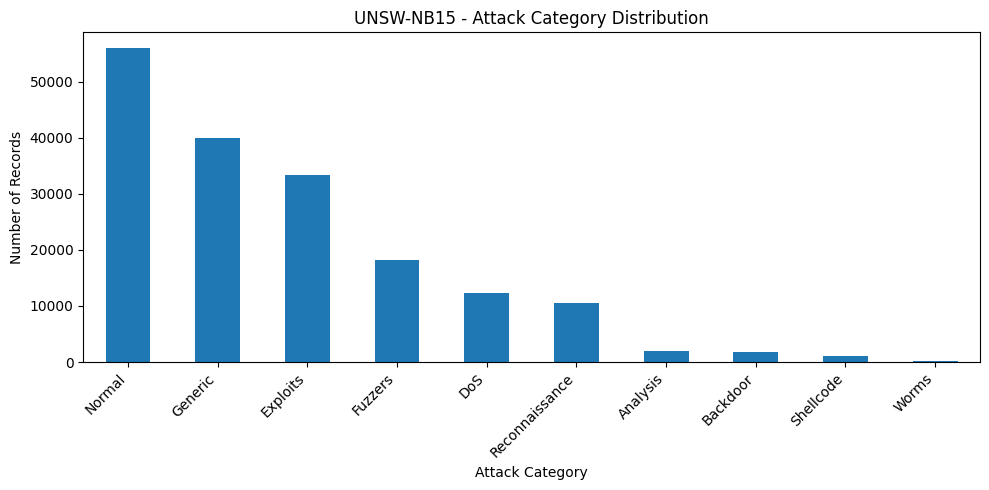

In [26]:
import matplotlib.pyplot as plt

attack_counts = df_unsw["attack_cat"].value_counts()

plt.figure(figsize=(10, 5))
attack_counts.plot(kind="bar")

plt.title("UNSW-NB15 - Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [27]:
print("=== Duplicate Rows ===")
duplicate_count = df_unsw.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

print("\n=== Unique Values ===")
print("Unique protocols:", df_unsw["proto"].nunique())
print("Unique services:", df_unsw["service"].nunique())
print("Unique states:", df_unsw["state"].nunique())

print("\n=== Basic Statistics ===")
print(df_unsw.describe().T)

=== Duplicate Rows ===
Total duplicate rows: 0

=== Unique Values ===
Unique protocols: 133
Unique services: 13
Unique states: 9

=== Basic Statistics ===
                      count          mean           std   min           25%  \
id                 175341.0  8.767100e+04  5.061673e+04   1.0  43836.000000   
dur                175341.0  1.359389e+00  6.480249e+00   0.0      0.000008   
spkts              175341.0  2.029866e+01  1.368876e+02   1.0      2.000000   
dpkts              175341.0  1.896959e+01  1.102583e+02   0.0      0.000000   
sbytes             175341.0  8.844844e+03  1.747656e+05  28.0    114.000000   
dbytes             175341.0  1.492892e+04  1.436542e+05   0.0      0.000000   
rate               175341.0  9.540619e+04  1.654010e+05   0.0     32.786140   
sttl               175341.0  1.795470e+02  1.029400e+02   0.0     62.000000   
dttl               175341.0  7.960957e+01  1.105069e+02   0.0      0.000000   
sload              175341.0  7.345403e+07  1.883574e+08

In [28]:
print("=== Protocol Distribution ===")
print(df_unsw["proto"].value_counts().head(15))

print("\n=== Service Distribution ===")
print(df_unsw["service"].value_counts())

print("\n=== State Distribution ===")
print(df_unsw["state"].value_counts())

=== Protocol Distribution ===
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
pim         201
swipe       201
sun-nd      201
rsvp        200
sep         193
Name: count, dtype: int64

=== Service Distribution ===
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

=== State Distribution ===
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [29]:
numeric_df = df_unsw.select_dtypes(include="number")

correlation = numeric_df.corr()

high_corr = (
    correlation.abs()
    .where(~np.eye(correlation.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
)

print("=== Top 15 Highly Correlated Feature Pairs ===")
print(high_corr.head(15))

=== Top 15 Highly Correlated Feature Pairs ===
is_ftp_login    ct_ftp_cmd        1.000000
ct_ftp_cmd      is_ftp_login      1.000000
dloss           dbytes            0.996504
dbytes          dloss             0.996504
sbytes          sloss             0.996109
sloss           sbytes            0.996109
dwin            swin              0.990140
swin            dwin              0.990140
ct_srv_dst      ct_srv_src        0.980323
ct_srv_src      ct_srv_dst        0.980323
dloss           dpkts             0.978636
dpkts           dloss             0.978636
ct_dst_src_ltm  ct_srv_dst        0.972370
ct_srv_dst      ct_dst_src_ltm    0.972370
dbytes          dpkts             0.971907
dtype: float64


In [30]:
import pandas as pd
import numpy as np

# CICIDS2017 Wednesday dataset
file_path = "/kaggle/input/datasets/challa2403/cicids2017-machine-learning-csv/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv"

df_cicids = pd.read_csv(file_path)

print("Original Shape:", df_cicids.shape)

# Remove extra spaces from column names
df_cicids.columns = df_cicids.columns.str.strip()

# Remove leading/trailing spaces from label values
df_cicids["Label"] = df_cicids["Label"].astype(str).str.strip()

print("\nColumn names cleaned.")
print("Number of columns:", len(df_cicids.columns))
print("\nLabels:")
print(df_cicids["Label"].value_counts())

Original Shape: (692703, 79)

Column names cleaned.
Number of columns: 79

Labels:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


In [31]:
# Check missing values
missing_values = df_cicids.isnull().sum().sum()

# Check infinite values
numeric_cols = df_cicids.select_dtypes(include=np.number).columns
inf_values = np.isinf(df_cicids[numeric_cols]).sum().sum()

print("Total Missing Values:", missing_values)
print("Total Infinite Values:", inf_values)

Total Missing Values: 1008
Total Infinite Values: 1586


In [32]:
# Missing values by column
missing_by_column = df_cicids.isnull().sum()
missing_by_column = missing_by_column[missing_by_column > 0]

print("=== Missing Values by Column ===")
print(missing_by_column)

# Infinite values by column
inf_by_column = np.isinf(df_cicids[numeric_cols]).sum()
inf_by_column = inf_by_column[inf_by_column > 0]

print("\n=== Infinite Values by Column ===")
print(inf_by_column)

=== Missing Values by Column ===
Flow Bytes/s    1008
dtype: int64

=== Infinite Values by Column ===
Flow Bytes/s       289
Flow Packets/s    1297
dtype: int64


In [33]:
# Convert infinite values to NaN
df_cicids.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing numeric values with median
for col in numeric_cols:
    if df_cicids[col].isnull().sum() > 0:
        df_cicids[col] = df_cicids[col].fillna(df_cicids[col].median())

print("Total Missing Values After Cleaning:",
      df_cicids.isnull().sum().sum())

print("Total Infinite Values After Cleaning:",
      np.isinf(df_cicids[numeric_cols]).sum().sum())

Total Missing Values After Cleaning: 0
Total Infinite Values After Cleaning: 0


In [34]:
# Check duplicate rows
duplicate_count = df_cicids.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

# Remove duplicate rows
df_cicids = df_cicids.drop_duplicates().reset_index(drop=True)

print("Shape After Removing Duplicates:", df_cicids.shape)

Duplicate Rows: 81909
Shape After Removing Duplicates: (610794, 79)


In [35]:
print("=== Final Cleaning Verification ===")

print("Dataset Shape:", df_cicids.shape)

print("Missing Values:",
      df_cicids.isnull().sum().sum())

print("Infinite Values:",
      np.isinf(
          df_cicids.select_dtypes(include=np.number)
      ).sum().sum())

print("Duplicate Rows:",
      df_cicids.duplicated().sum())

print("\nLabel Distribution:")
print(df_cicids["Label"].value_counts())

=== Final Cleaning Verification ===
Dataset Shape: (610794, 79)
Missing Values: 0
Infinite Values: 0
Duplicate Rows: 0

Label Distribution:
Label
BENIGN              417035
DoS Hulk            172849
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64


In [42]:
# UNSW-NB15 Training Dataset
train_path = "/kaggle/input/datasets/challa2403/unsw-nb15-dataset/UNSW_NB15_training-set.csv"

df_unsw_clean = pd.read_csv(train_path)

print("Original Shape:", df_unsw_clean.shape)

# Clean column names
df_unsw_clean.columns = df_unsw_clean.columns.str.strip()

print("No.of Columns:", len(df_unsw_clean.columns))

Original Shape: (175341, 45)
No.of Columns: 45


In [37]:
# Check missing values
missing_values = df_unsw_clean.isnull().sum().sum()

# Check infinite values in numeric columns
numeric_cols_unsw = df_unsw_clean.select_dtypes(include=np.number).columns
inf_values = np.isinf(df_unsw_clean[numeric_cols_unsw]).sum().sum()

print("Total Missing Values:", missing_values)
print("Total Infinite Values:", inf_values)

Total Missing Values: 0
Total Infinite Values: 0


In [38]:
# Check the duplicate rows
duplicate_count = df_unsw_clean.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [39]:
print("=== UNSW-NB15 Final Cleaning Verification ===")

print("Dataset Shape:", df_unsw_clean.shape)

print("Missing Values:",
      df_unsw_clean.isnull().sum().sum())

print("Infinite Values:",
      np.isinf(
          df_unsw_clean.select_dtypes(include=np.number)
      ).sum().sum())

print("Duplicate Rows:",
      df_unsw_clean.duplicated().sum())

print("\nBinary Label Distribution:")
print(df_unsw_clean["label"].value_counts())

print("\nAttack Category Distribution:")
print(df_unsw_clean["attack_cat"].value_counts())

=== UNSW-NB15 Final Cleaning Verification ===
Dataset Shape: (175341, 45)
Missing Values: 0
Infinite Values: 0
Duplicate Rows: 0

Binary Label Distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Attack Category Distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [40]:

# UNSW-NB15 - Data Cleaning & Preprocessing

import pandas as pd
import numpy as np

# Load dataset
train_path = "/kaggle/input/datasets/challa2403/unsw-nb15-dataset/UNSW_NB15_training-set.csv"

df_unsw_clean = pd.read_csv(train_path)

print("Original Shape:", df_unsw_clean.shape)

# Clean column names
df_unsw_clean.columns = df_unsw_clean.columns.str.strip()

# Check missing values
missing_values = df_unsw_clean.isnull().sum().sum()

# Check infinite values
numeric_cols_unsw = df_unsw_clean.select_dtypes(include=np.number).columns
inf_values = np.isinf(df_unsw_clean[numeric_cols_unsw]).sum().sum()

print("Total Missing Values:", missing_values)
print("Total Infinite Values:", inf_values)

# Check and remove duplicate rows
duplicate_count = df_unsw_clean.duplicated().sum()

print("Duplicate Rows Before Cleaning:", duplicate_count)

df_unsw_clean = df_unsw_clean.drop_duplicates().reset_index(drop=True)

# Final verification
print("\n=== Final Cleaning Verification ===")
print("Dataset Shape:", df_unsw_clean.shape)

print("Missing Values:",
      df_unsw_clean.isnull().sum().sum())

print("Infinite Values:",
      np.isinf(
          df_unsw_clean.select_dtypes(include=np.number)
      ).sum().sum())

print("Duplicate Rows:",
      df_unsw_clean.duplicated().sum())

print("\nBinary Label Distribution:")
print(df_unsw_clean["label"].value_counts())

print("\nAttack Category Distribution:")
print(df_unsw_clean["attack_cat"].value_counts())

Original Shape: (175341, 45)
Total Missing Values: 0
Total Infinite Values: 0
Duplicate Rows Before Cleaning: 0

=== Final Cleaning Verification ===
Dataset Shape: (175341, 45)
Missing Values: 0
Infinite Values: 0
Duplicate Rows: 0

Binary Label Distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Attack Category Distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [ ]:

# Final EDA & Cleaning Conclusion


print("=== Final Conclusion ===")

print("""
CICIDS2017 and UNSW-NB15 were analyzed for the
Network Anomaly Detection and Predictive Intrusion
Monitoring Platform.

CICIDS2017 required preprocessing to handle missing
values, infinite values, and duplicate records.
After cleaning, the dataset contained 610,794 records
and 79 columns.

UNSW-NB15 contained no missing values, infinite values,
or duplicate records in the official training set.
The dataset contains 175,341 records and 45 columns.

Both datasets contain normal and attack traffic and
provide useful network-flow features for intrusion
detection.

The datasets are suitable for further preprocessing,
feature engineering, model training, prediction, and
evaluation using metrics such as Precision, Recall,
and F1-score.
""")

=== Final Conclusion ===

CICIDS2017 and UNSW-NB15 were analyzed for the
Network Anomaly Detection and Predictive Intrusion
Monitoring Platform.

CICIDS2017 required preprocessing to handle missing
values, infinite values, and duplicate records.
After cleaning, the dataset contained 610,794 records
and 79 columns.

UNSW-NB15 contained no missing values, infinite values,
or duplicate records in the official training set.
The dataset contains 175,341 records and 45 columns.

Both datasets contain normal and attack traffic and
provide useful network-flow features for intrusion
detection.

The datasets are suitable for further preprocessing,
feature engineering, model training, prediction, and
evaluation using metrics such as Precision, Recall,
and F1-score.

